# Exp7.2.6 — Output Readout Loss & Representation Shaping

Analysis-only notebook. It reads finalized aggregate artifacts; training, checkpoint loading, inference, gain calibration, and Slurm dispatch are intentionally excluded.


In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

def find_repo_root(start=None):
    path = (start or Path.cwd()).resolve()
    for candidate in (path, *path.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'scripts').exists():
            return candidate
    raise FileNotFoundError('Could not find repository root')

REPO_ROOT = find_repo_root()
ROOT = REPO_ROOT / 'notebooks' / 'artifacts' / 'experiment_7_2_6_output_readout_loss_shaping' / 'output_readout_loss_shaping_v1'
ROOT


PosixPath('/home/zhaolongwei_umass_edu/projects/writingRing/notebooks/artifacts/experiment_7_2_6_output_readout_loss_shaping/output_readout_loss_shaping_v1')

## Finalized inputs


In [2]:
manifest = json.loads((ROOT / 'manifest.json').read_text())
cross = pd.read_csv(ROOT / 'crosscheck_2x2_summary.csv')
ladder = pd.read_csv(ROOT / 'mechanism_ladder_summary.csv')
beta = pd.read_csv(ROOT / 'beta_sweep_summary.csv')
controls = pd.read_csv(ROOT / 'cap_polarity_controls.csv')
e2e = pd.read_csv(ROOT / 'e2e_performance_summary.csv')
probes = pd.read_csv(ROOT / 'e2e_l2_probe_summary.csv')
deltas = pd.read_csv(ROOT / 'representation_shaping_delta_summary.csv')
manifest


{'architecture': '234x234',
 'checkpoint_selection': 'validation valid-length WholeCount BA; validation loss tie-break',
 'e2e_pairing': 'C0/C1 reuse exact Exp7.2.5 C2 model-init and loader seed stream',
 'experiment_id': 'experiment_7_2_6_output_readout_loss_shaping',
 'frozen_head_training_runs': 12,
 'gain_calibration': 'validation-only beta=1 cap=1 IF; fixed thereafter',
 'mechanism_tasks': 6,
 'new_e2e_training_runs': 12,
 'notebook_inputs': ['crosscheck_2x2_summary.csv',
  'mechanism_ladder_summary.csv',
  'beta_sweep_summary.csv',
  'cap_polarity_controls.csv',
  'e2e_performance_summary.csv',
  'e2e_l2_probe_summary.csv',
  'representation_shaping_delta_summary.csv',
  'report_task_only_crosscheck.csv',
  'report_task_only_mechanism.csv',
  'report_task_only_e2e.csv',
  'report_task_plus_reg_crosscheck.csv',
  'report_task_plus_reg_mechanism.csv',
  'report_task_plus_reg_e2e.csv'],
 'objective': 'whole_count_ce',
 'probe_tasks_including_reused_c2': 18,
 'protocol_version': 'out

## Part I — Frozen-L2 decoding mechanism


In [3]:
display(cross[cross.regularization == 'task_only'])
display(ladder[ladder.regularization == 'task_only'])


,architecture,regularization,condition,n,accuracy_mean,balanced_accuracy_mean,macro_f1_mean,accuracy_std,balanced_accuracy_std,macro_f1_std
0,234x234,task_only,X1_wlin_analog,3,0.385845,0.379799,0.361729,0.044035,0.046748,0.053319
1,234x234,task_only,X2_wlin_lif_beta05,3,0.340183,0.326749,0.310643,0.055362,0.051865,0.063775
2,234x234,task_only,X3_wlif_analog,3,0.356164,0.343219,0.310413,0.071509,0.069137,0.083233
3,234x234,task_only,X4_wlif_lif_beta05,3,0.356164,0.334776,0.309705,0.066052,0.065135,0.073808


,architecture,regularization,block,condition,n,accuracy_mean,balanced_accuracy_mean,macro_f1_mean,accuracy_std,balanced_accuracy_std,macro_f1_std
0,234x234,task_only,direction_a,A0_wlif_lif_beta05,3,0.356164,0.334776,0.309705,0.066052,0.065135,0.073808
1,234x234,task_only,direction_a,A1_wlif_if_beta1_spike,3,0.315068,0.302550,0.274501,0.077188,0.077522,0.088410
2,234x234,task_only,direction_a,A2_wlif_if_beta1_charge,3,0.356164,0.343219,0.310413,0.071509,0.069137,0.083233
3,234x234,task_only,direction_a,A3_wlif_analog,3,0.356164,0.343219,0.310413,0.071509,0.069137,0.083233
4,234x234,task_only,direction_b,B0_wlin_analog,3,0.385845,0.379799,0.361729,0.044035,0.046748,0.053319
5,234x234,task_only,direction_b,B1_if_beta1_charge,3,0.385845,0.379799,0.361729,0.044035,0.046748,0.053319
6,234x234,task_only,direction_b,B2_if_beta1_spike,3,0.381279,0.375678,0.361106,0.057442,0.057094,0.060318
7,234x234,task_only,direction_b,B2a_if_beta1_cap31,3,0.385845,0.378617,0.361508,0.049549,0.050073,0.057194
8,234x234,task_only,direction_b,B2b_if_beta1_bipolar,3,0.378995,0.374310,0.357687,0.057032,0.058847,0.062218
9,234x234,task_only,direction_b,B3_lif_beta05_spike,3,0.340183,0.326749,0.310643,0.055362,0.051865,0.063775


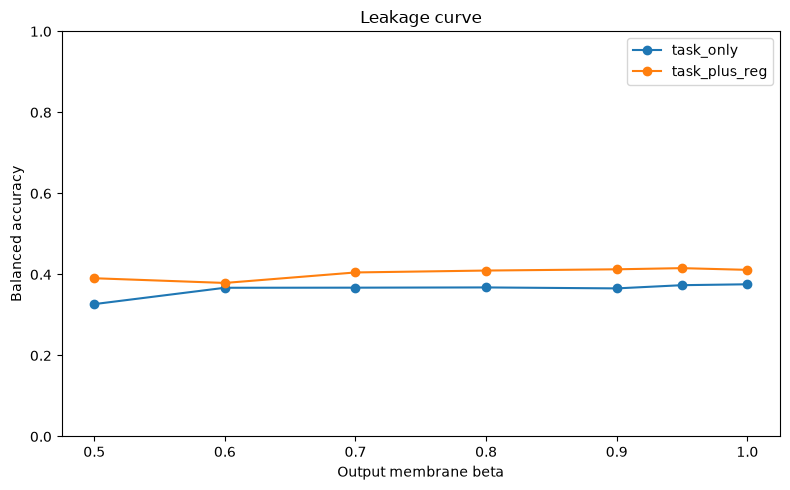

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
for regularization, group in beta.groupby('regularization'):
    ordered = group.sort_values('beta')
    ax.plot(ordered.beta, ordered.balanced_accuracy_mean, marker='o', label=regularization)
ax.set_xlabel('Output membrane beta')
ax.set_ylabel('Balanced accuracy')
ax.set_ylim(0, 1)
ax.set_title('Leakage curve')
ax.legend()
fig.tight_layout()
plt.show()


In [5]:
display(controls)


,architecture,regularization,seed,block,condition,accuracy,balanced_accuracy,macro_f1
0,234x234,task_only,11,direction_b,B2_if_beta1_spike,0.410959,0.404509,0.394227
1,234x234,task_only,11,direction_b,B2a_if_beta1_cap31,0.410959,0.402128,0.391351
2,234x234,task_only,11,direction_b,B2b_if_beta1_bipolar,0.397260,0.391612,0.381740
3,234x234,task_only,11,direction_b,B3_lif_beta05_spike,0.349315,0.337693,0.321160
4,234x234,task_only,11,direction_b,B3a_lif_beta05_cap31,0.349315,0.337693,0.321160
5,234x234,task_only,11,direction_b,B3b_lif_beta05_bipolar,0.356164,0.344103,0.326577
6,234x234,task_only,23,direction_b,B2_if_beta1_spike,0.315068,0.309917,0.291484
7,234x234,task_only,23,direction_b,B2a_if_beta1_cap31,0.328767,0.321114,0.295566
8,234x234,task_only,23,direction_b,B2b_if_beta1_bipolar,0.315068,0.308752,0.287032
9,234x234,task_only,23,direction_b,B3_lif_beta05_spike,0.280822,0.270285,0.242264


## Part II — E2E representation shaping


In [6]:
display(e2e)
display(probes)
display(deltas)


,architecture,regularization,condition,split,n,accuracy_mean,balanced_accuracy_mean,macro_f1_mean,accuracy_std,balanced_accuracy_std,macro_f1_std
0,234x234,task_only,c0_analog,test,3,0.413242,0.403920,0.387476,0.033787,0.024700,0.020277
1,234x234,task_only,c0_analog,train,3,0.891566,0.892791,0.896663,0.014706,0.014720,0.013253
2,234x234,task_only,c0_analog,val,3,0.396825,0.393296,0.395578,0.020998,0.015756,0.007815
3,234x234,task_only,c1_if_beta10,test,3,0.237443,0.228095,0.186261,0.062149,0.054497,0.053338
4,234x234,task_only,c1_if_beta10,train,3,0.442915,0.435771,0.444627,0.154928,0.157200,0.168317
5,234x234,task_only,c1_if_beta10,val,3,0.238095,0.242869,0.212635,0.070541,0.069854,0.086489
6,234x234,task_only,c2_lif_beta05_reuse,test,3,0.442922,0.432093,0.408350,0.030885,0.035848,0.044133
7,234x234,task_only,c2_lif_beta05_reuse,train,3,0.828457,0.825340,0.826022,0.088139,0.093563,0.095537
8,234x234,task_only,c2_lif_beta05_reuse,val,3,0.447090,0.434402,0.420545,0.032075,0.028774,0.044183
9,234x234,task_plus_reg,c0_analog,test,3,0.417808,0.411276,0.400117,0.029855,0.028578,0.027503


,architecture,regularization,condition,probe,split,n,accuracy_mean,balanced_accuracy_mean,macro_f1_mean,accuracy_std,balanced_accuracy_std,macro_f1_std
0,234x234,task_only,c0_analog,l2_fixed250_linear,test,3,0.484018,0.475154,0.472445,0.039545,0.036803,0.039336
1,234x234,task_only,c0_analog,l2_fixed250_linear,train,3,0.921400,0.920487,0.932216,0.011199,0.011668,0.008912
2,234x234,task_only,c0_analog,l2_fixed250_linear,val,3,0.433862,0.416785,0.427819,0.050404,0.047161,0.049179
3,234x234,task_only,c0_analog,l2_wholecount_linear,test,3,0.436073,0.422473,0.395668,0.024054,0.028997,0.036609
4,234x234,task_only,c0_analog,l2_wholecount_linear,train,3,0.825588,0.818123,0.834915,0.122207,0.132523,0.124081
5,234x234,task_only,c0_analog,l2_wholecount_linear,val,3,0.433862,0.413005,0.414859,0.037506,0.037387,0.048182
6,234x234,task_only,c0_analog,l2_wholecount_matched_biasfree,test,3,0.413242,0.404869,0.383189,0.043499,0.041701,0.047386
7,234x234,task_only,c0_analog,l2_wholecount_matched_biasfree,train,3,0.858290,0.858957,0.863776,0.027824,0.027749,0.026691
8,234x234,task_only,c0_analog,l2_wholecount_matched_biasfree,val,3,0.373016,0.373609,0.368234,0.034594,0.036571,0.038885
9,234x234,task_only,c1_if_beta10,l2_fixed250_linear,test,3,0.347032,0.339712,0.323064,0.075135,0.064825,0.071269


,regularization,probe,contrast,n,delta_mean,delta_std
0,task_only,l2_fixed250_linear,analog_minus_if,3,0.135441,0.046446
1,task_only,l2_fixed250_linear,analog_minus_lif,3,-0.089608,0.064492
2,task_only,l2_fixed250_linear,if_minus_lif,3,-0.225049,0.099466
3,task_only,l2_wholecount_linear,analog_minus_if,3,0.118987,0.032341
4,task_only,l2_wholecount_linear,analog_minus_lif,3,-0.102198,0.065822
5,task_only,l2_wholecount_linear,if_minus_lif,3,-0.221185,0.094458
6,task_only,l2_wholecount_matched_biasfree,analog_minus_if,3,0.151519,0.041037
7,task_only,l2_wholecount_matched_biasfree,analog_minus_lif,3,0.025174,0.064357
8,task_only,l2_wholecount_matched_biasfree,if_minus_lif,3,-0.126344,0.105352
9,task_plus_reg,l2_fixed250_linear,analog_minus_if,3,0.148314,0.034281


In [7]:
test_probe = probes[probes.split == 'test'].copy()
comparison = test_probe.pivot_table(
    index=['regularization', 'probe'],
    columns='condition',
    values='balanced_accuracy_mean',
    aggfunc='first',
).reset_index()
display(comparison)


condition,regularization,probe,c0_analog,c1_if_beta10,c2_lif_beta05_reuse
0,task_only,l2_fixed250_linear,0.475154,0.339712,0.564762
1,task_only,l2_wholecount_linear,0.422473,0.303487,0.524671
2,task_only,l2_wholecount_matched_biasfree,0.404869,0.253350,0.379695
3,task_plus_reg,l2_fixed250_linear,0.466602,0.318288,0.556687
4,task_plus_reg,l2_wholecount_linear,0.442404,0.278551,0.527332
5,task_plus_reg,l2_wholecount_matched_biasfree,0.379717,0.208565,0.418076
